# Planner Tests

Most data from lecture_examples/IP-X-1-Automated_PlanerTest.ipynb

Adding all planners
===========


In [1]:
import sys
from pathlib import Path
import matplotlib.pylab as plt
%matplotlib inline
import traceback

# Define paths
REPO_ROOT = Path.cwd().parent               # Repo root (ikp-sbl)
LECTURE_EXAMPLES = REPO_ROOT / "lecture_examples"

# Add BOTH to sys.path
for path in [str(REPO_ROOT), str(LECTURE_EXAMPLES)]:
    if path not in sys.path:
        sys.path.insert(0, path)

# 1. Imports from lecture_examples
from IPPerfMonitor import IPPerfMonitor
import IPBasicPRM
import IPVISBasicPRM
import IPLazyPRM
import IPVISLazyPRM
import IPRRT
import IPVISRRT

# 2. Other imports
from planners.SBL import BidirectionalSBL
from modules import IPVISsbl
# from modules import draw

Set-up of the test scenario and the configuration for all planners
===================================

Following a procedure to compare all discussed planners are shown:

1. Configuration for every planner is defined
2. The configuration and the planner is stored in the variable setup, a Python dict()
3. The variable setup is then used to uniformly execute the planners


In [2]:
# Create a factory for your parameter variations
plannerFactory = dict()

config = BidirectionalSBL.DEFAULT_CONFIG.copy()
config["eta"] = 2.0
plannerFactory[f"SBL"] = [BidirectionalSBL, config, IPVISsbl.sblVisualize]

# Example: Testing different Eta settings
# for eta in [0.5, 1.0, 2.0]:
#     config = BidirectionalSBL.DEFAULT_CONFIG.copy()
#     config["eta"] = eta
#     plannerFactory[f"SBL_eta_{eta}"] = [BidirectionalSBL, config]

# # Example: Testing different Goal Bias settings
# for bias in [0.2, 0.5, 0.8]:
#     config = BidirectionalSBL.DEFAULT_CONFIG.copy()
#     config["goal_bias"] = bias
#     plannerFactory[f"SBL_bias_{bias}"] = [BidirectionalSBL, config]

In [3]:
basicConfig = dict()
basicConfig["radius"] = 3
basicConfig["numNodes"] = 200
plannerFactory["basePRM"] = [IPBasicPRM.BasicPRM, basicConfig, IPVISBasicPRM.basicPRMVisualize]

lazyConfig = dict()
lazyConfig["initialRoadmapSize"] = 10
lazyConfig["updateRoadmapSize"]  = 5 
lazyConfig["kNearest"] = 8
lazyConfig["maxIterations"] = 20
plannerFactory["lazyPRM"] = [IPLazyPRM.LazyPRM, lazyConfig, IPVISLazyPRM.lazyPRMVisualize]

rrtSimpleConfig = dict()
rrtSimpleConfig["numberOfGeneratedNodes"] = 100 
rrtSimpleConfig["testGoalAfterNumberOfNodes"]  = 10
plannerFactory["simpleRRT"] = [IPRRT.RRTSimple, rrtSimpleConfig, IPVISRRT.rrtPRMVisualize]




In [4]:
class ResultCollection (object):
    
    def __init__(self, plannerFactoryName, planner, benchmark, solution, perfDataFrame):
        self.plannerFactoryName = plannerFactoryName
        self.planner = planner
        self.benchmark = benchmark
        self.solution = solution
        self.perfDataFrame = perfDataFrame

In [5]:
import lecture_examples.IPTestSuite as ts
from shapely.geometry import Point, Polygon, LineString
from shapely import plotting


In [6]:
fullBenchList = ts.benchList

for benchmark in fullBenchList:
    print(benchmark.name)

Trap
Fat bottleneck
Open Space
Random Map


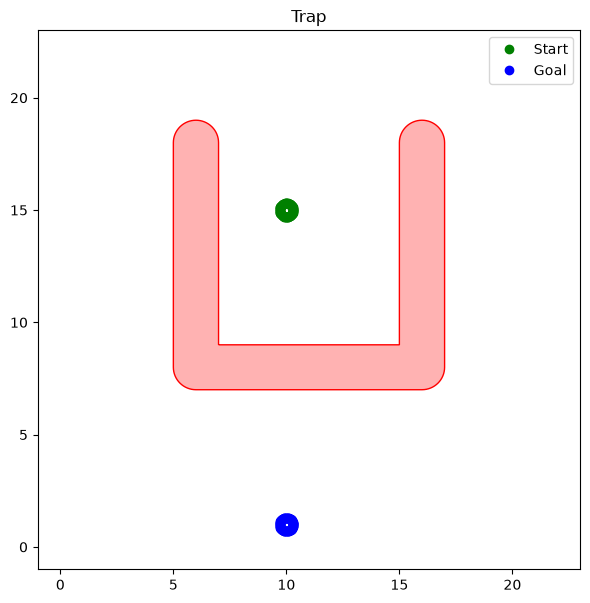

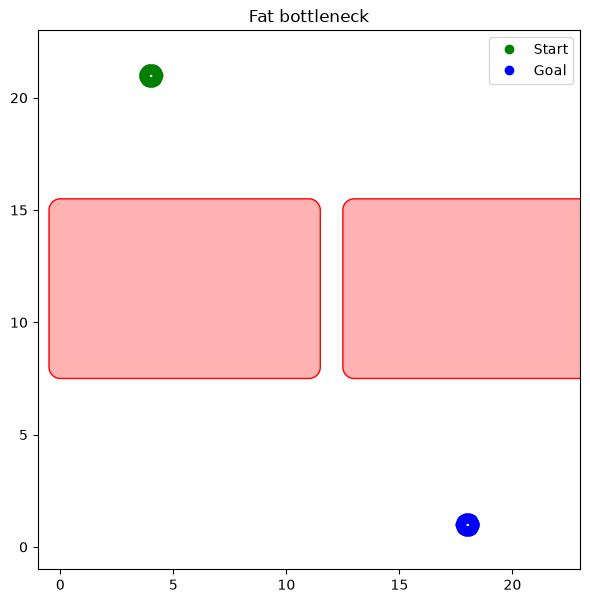

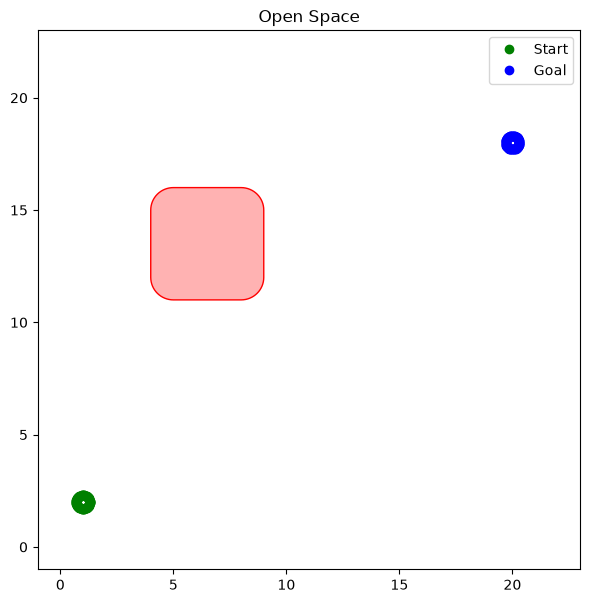

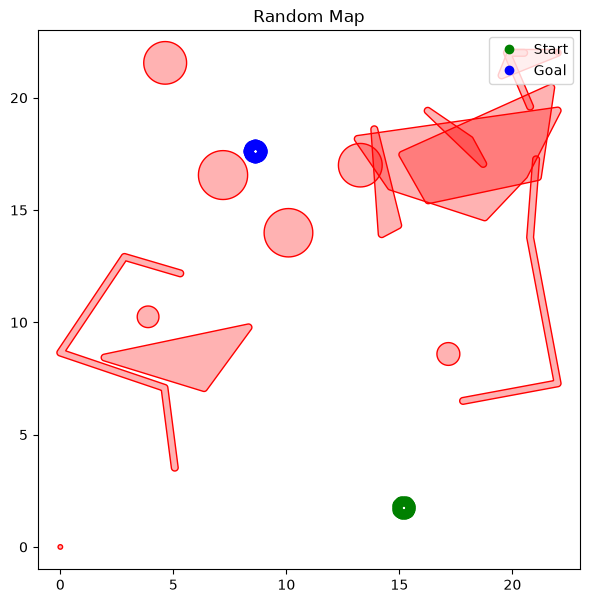

In [7]:
for benchmark in fullBenchList:
    fig_local = plt.figure(figsize=(7,7))
    ax = fig_local.add_subplot(1,1,1)
    title = benchmark.name
    ax.set_title(title)
    
    limits = benchmark.collisionChecker.getEnvironmentLimits()
    
    # Add a visual margin so the buffered points are not cropped at the map edges
    margin = 1.0 
    ax.set_xlim(limits[0][0] - margin, limits[0][1] + margin)
    ax.set_ylim(limits[1][0] - margin, limits[1][1] + margin)
    plotting.plot_points(Point(benchmark.startList[0]).buffer(.3), color="g", ax=ax, label="Start")
    plotting.plot_points(Point(benchmark.goalList[0]).buffer(.3), color="b", ax=ax, label="Goal")
    
    benchmark.collisionChecker.drawObstacles(ax)

    # Optional: add legend to easily identify start/goal
    ax.legend(loc="upper right")

In [8]:
resultList = list()
testList = fullBenchList

for key, producer in list(plannerFactory.items()):
    print(key, producer)

    planner_class = producer[0]
    config = producer[1]

    for benchmark in testList:
        print ("Planning: " + key + " - " + benchmark.name)
        # 1. Clear data from previous runs
        IPPerfMonitor.clearData()

        # 2. Instantiate and run
        # Note: Depending on the constructor, some planners might not accept config here. 
        # But based on our factory setup, we pass it down if they accept it.
        try:
            planner = planner_class(benchmark.collisionChecker, config=config)
        except TypeError:
            # Fallback if lecture planners don't accept config in their constructor
            planner = planner_class(benchmark.collisionChecker)
        
        try:
            path = planner.planPath(
                benchmark.startList, 
                benchmark.goalList, 
                config
            )

            # 4. Store result using the ResultCollection class
            resultList.append(
                ResultCollection(
                    key,
                    planner, 
                    benchmark, 
                    path, 
                    IPPerfMonitor.dataFrame()
                )
            )
            
        except Exception as e:
            # THIS WILL REVEAL THE EXACT CRASH!
            print(f"CRASH DETECTED for {key} on {benchmark.name}:")
            traceback.print_exc()
            print("-" * 40)


SBL [<class 'planners.SBL.BidirectionalSBL'>, {'max_nodes': 500, 'eta': 2.0, 'standard_eta': 1.5, 'eta_min': 0.05, 'eta_max': 5.0, 'eta_shrink': 0.5, 'eta_grow': 1.2, 'expand_attempts': 5, 'iterations': 10, 'collision_check': {'adaptive': True, 'epsilon': 0.05, 'steps': 50}, 'goal_bias': 0.5, 'repair_bias': 0.6, 'count_edge_checks': False, 'checkpoint_path': None}, <function sblVisualize at 0x1131aad40>]
Planning: SBL - Trap


100%|██████████| 10/10 [00:00<00:00, 276.75it/s]


Planning: SBL - Fat bottleneck


 40%|████      | 4/10 [00:00<00:00, 372.79it/s]


Planning: SBL - Open Space


  0%|          | 0/10 [00:00<?, ?it/s]


Planning: SBL - Random Map


 60%|██████    | 6/10 [00:00<00:00, 239.78it/s]

basePRM [<class 'IPBasicPRM.BasicPRM'>, {'radius': 3, 'numNodes': 200}, <function basicPRMVisualize at 0x112fd05e0>]
Planning: basePRM - Trap


Planning: basePRM - Fat bottleneck
Planning: basePRM - Open Space
Planning: basePRM - Random Map
lazyPRM [<class 'IPLazyPRM.LazyPRM'>, {'initialRoadmapSize': 10, 'updateRoadmapSize': 5, 'kNearest': 8, 'maxIterations': 20}, <function lazyPRMVisualize at 0x112fd0cc0>]
Planning: lazyPRM - Trap
Planning: lazyPRM - Fat bottleneck
Planning: lazyPRM - Open Space
Planning: lazyPRM - Random Map
simpleRRT [<class 'IPRRT.RRTSimple'>, {'numberOfGeneratedNodes': 100, 'testGoalAfterNumberOfNodes': 10}, <function rrtPRMVisualize at 0x112fd0fe0>]
Planning: simpleRRT - Trap
Planning: simpleRRT - Fat bottleneck
Planning: simpleRRT - Open Space
Planning: simpleRRT - Random Map


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/networkx/drawing/nx_pylab.py:1497: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


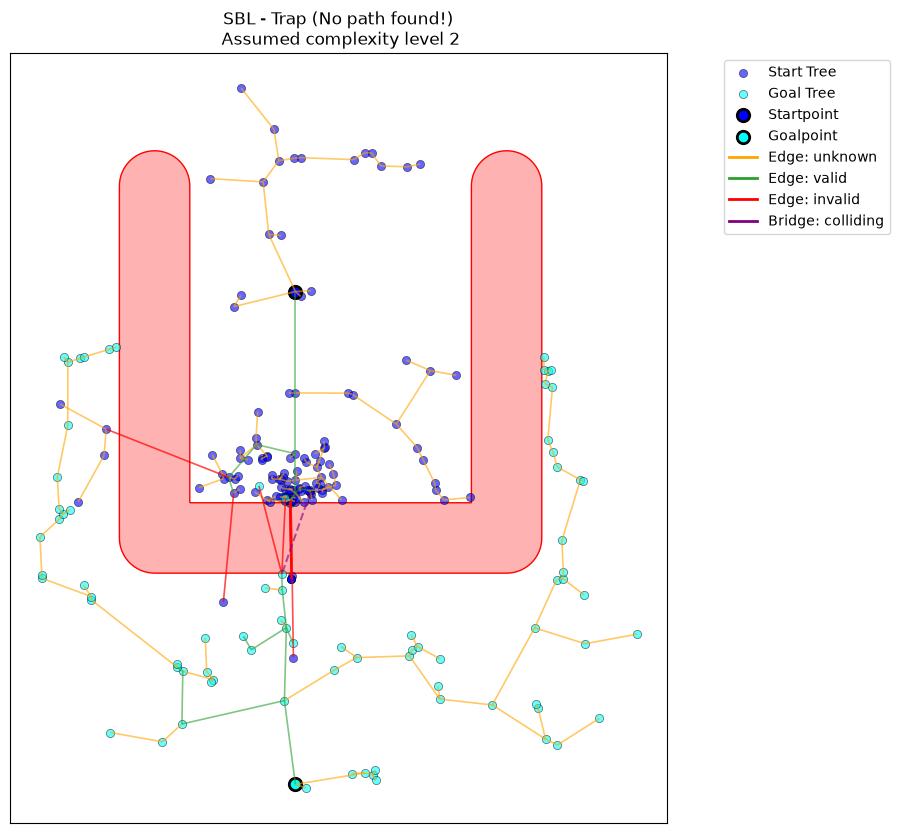

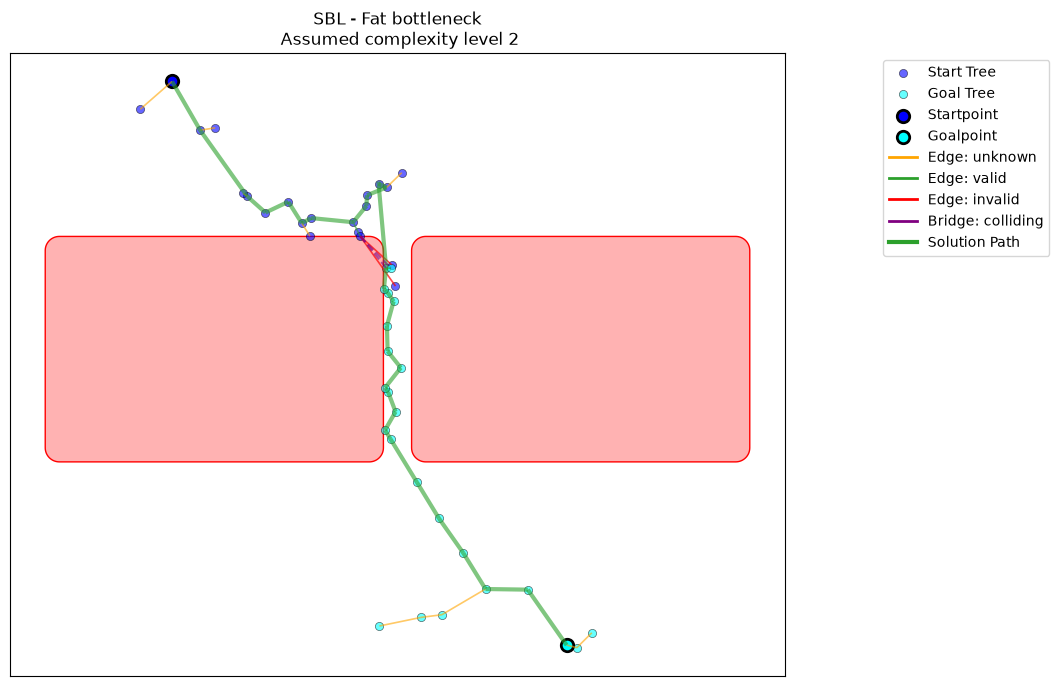

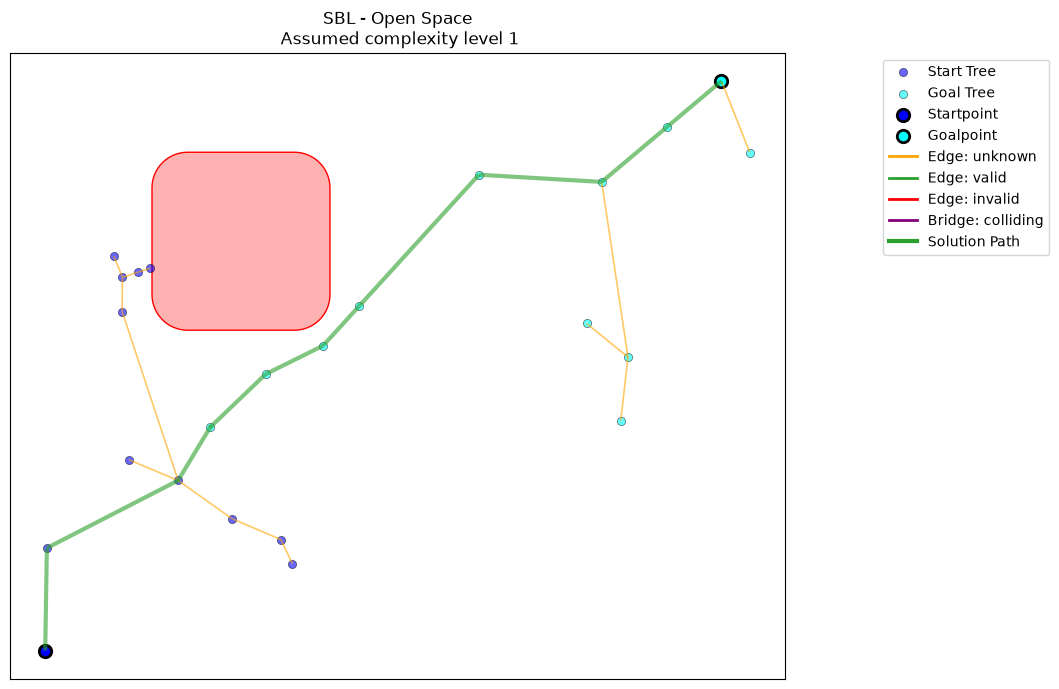

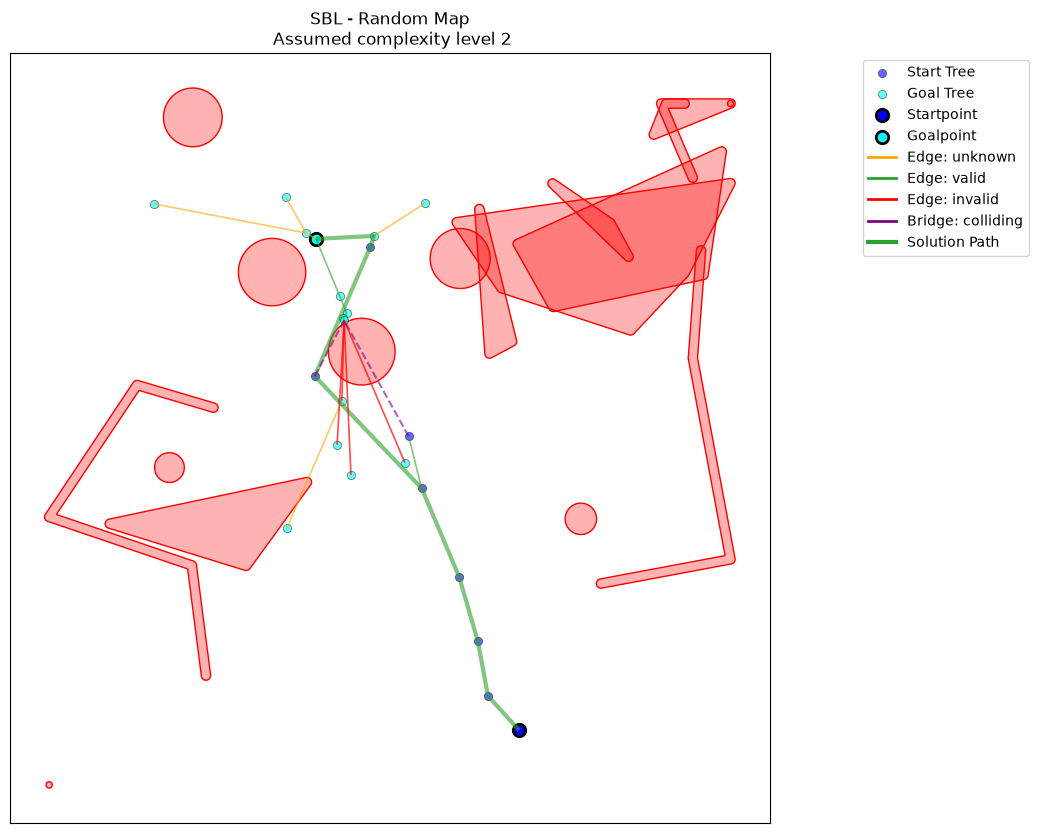

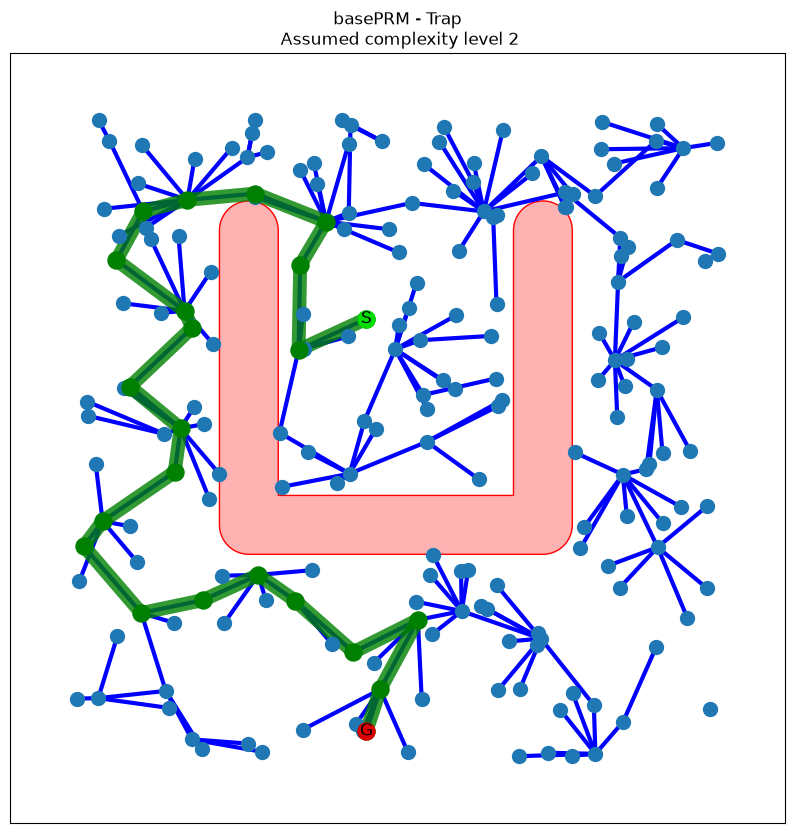

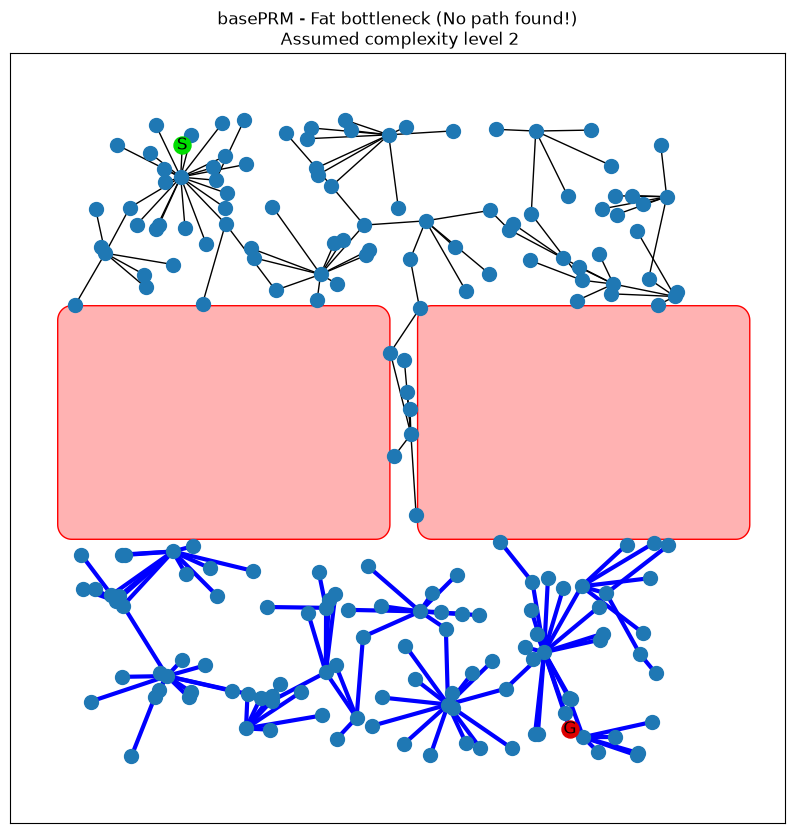

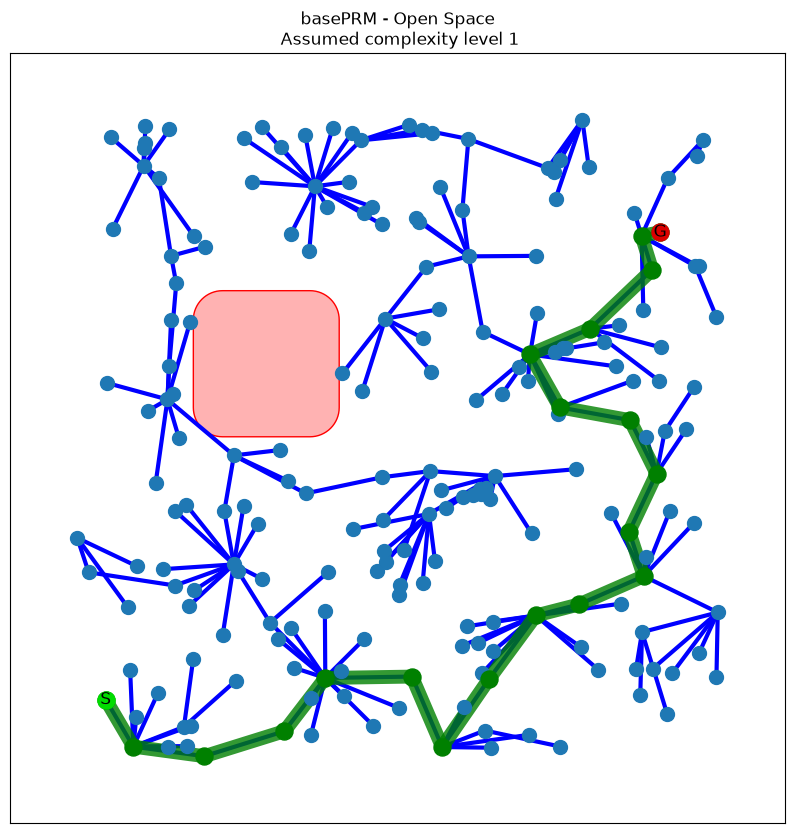

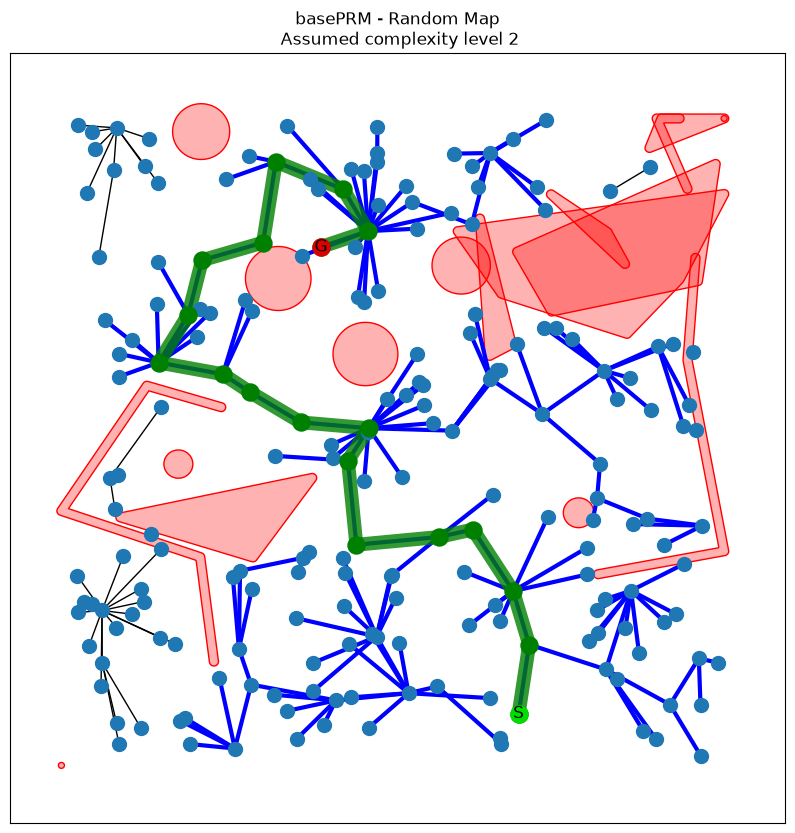

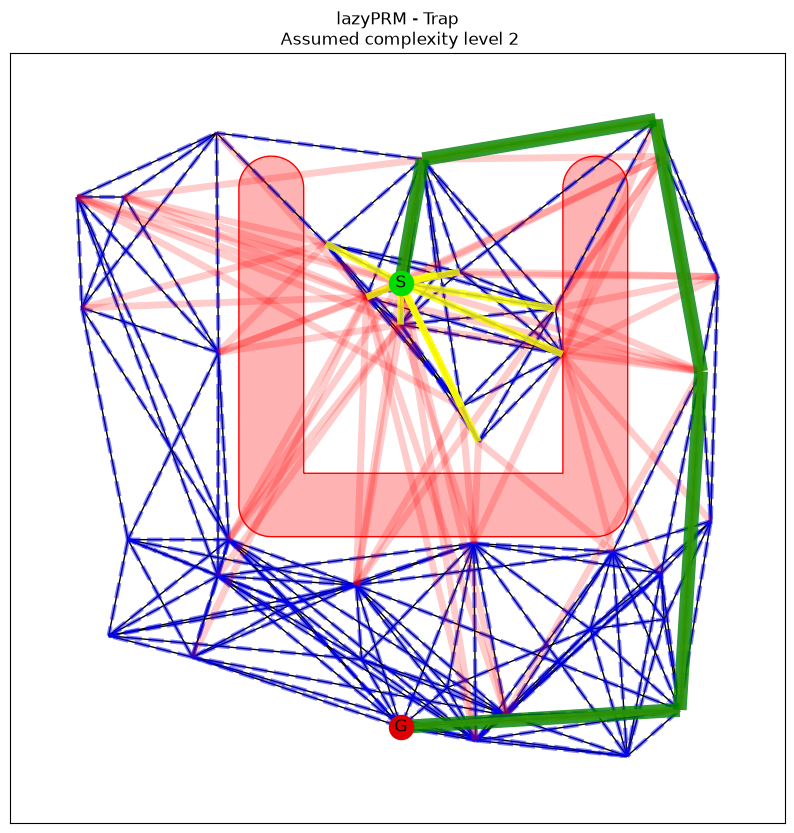

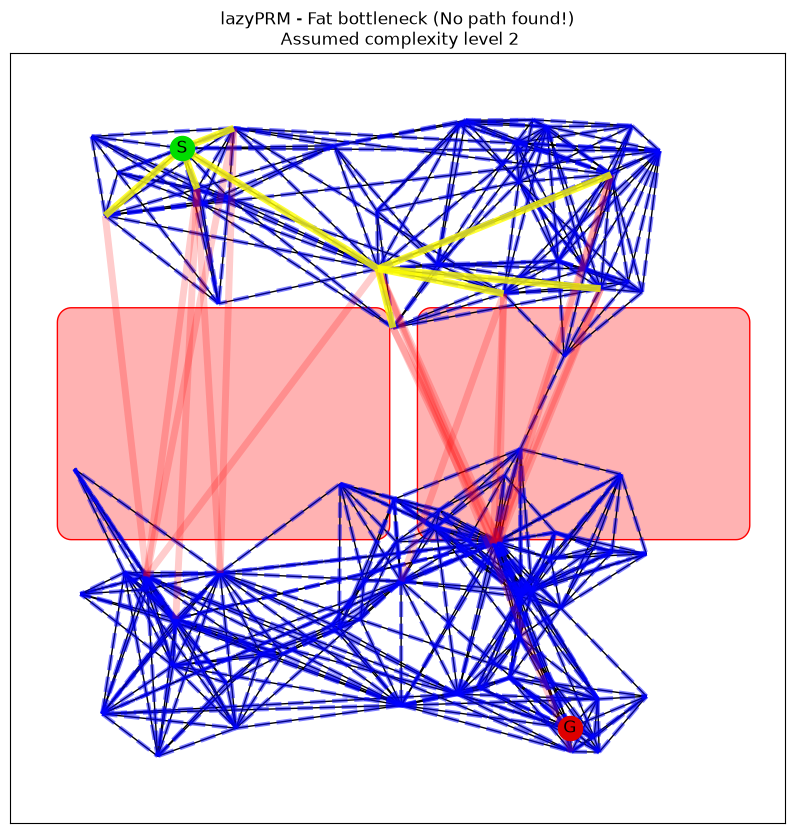

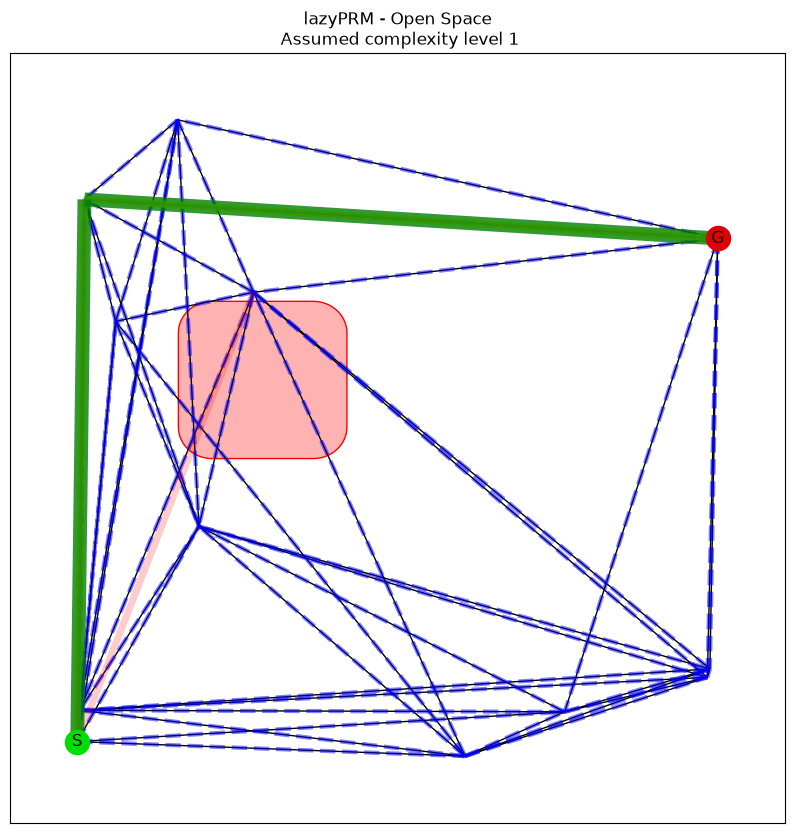

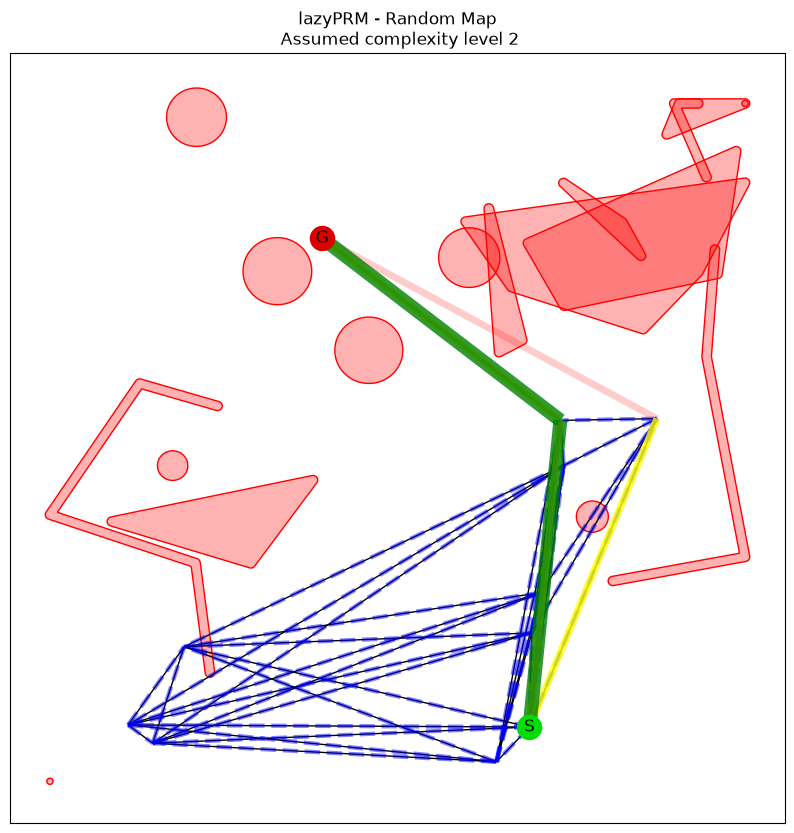

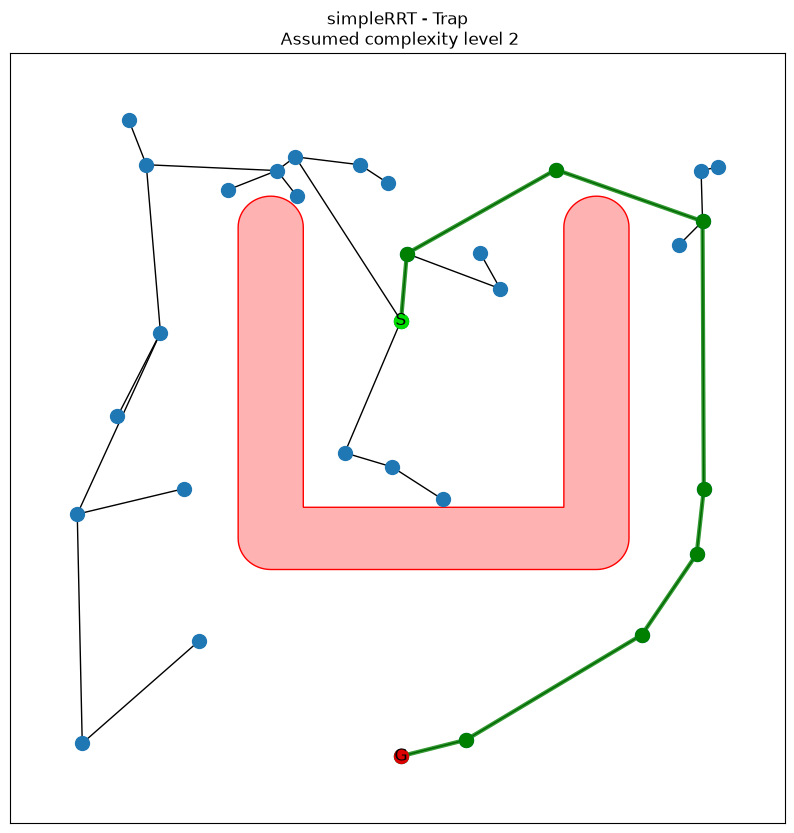

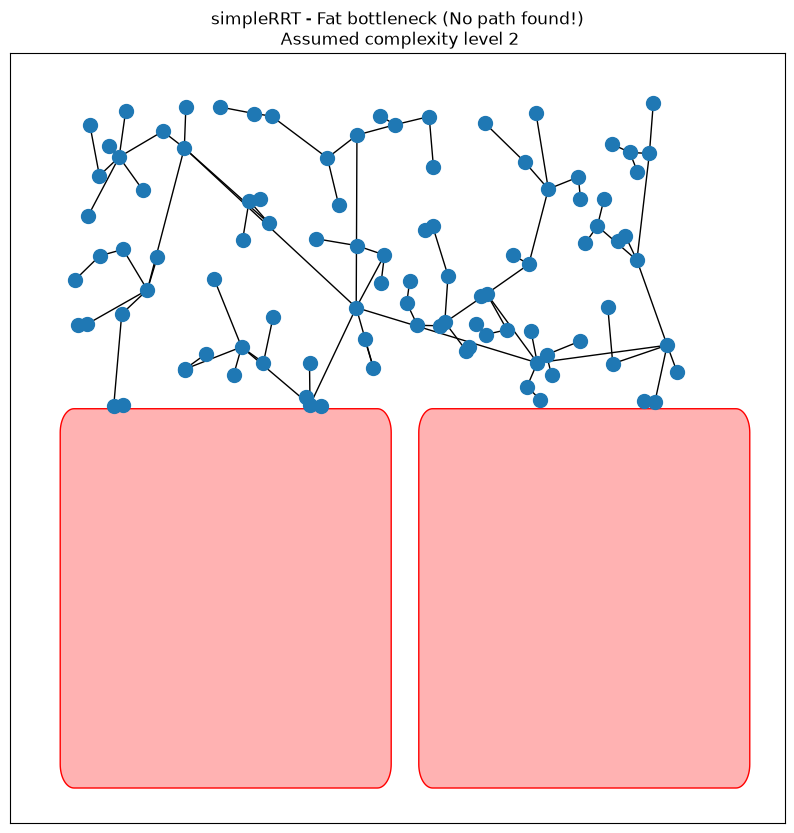

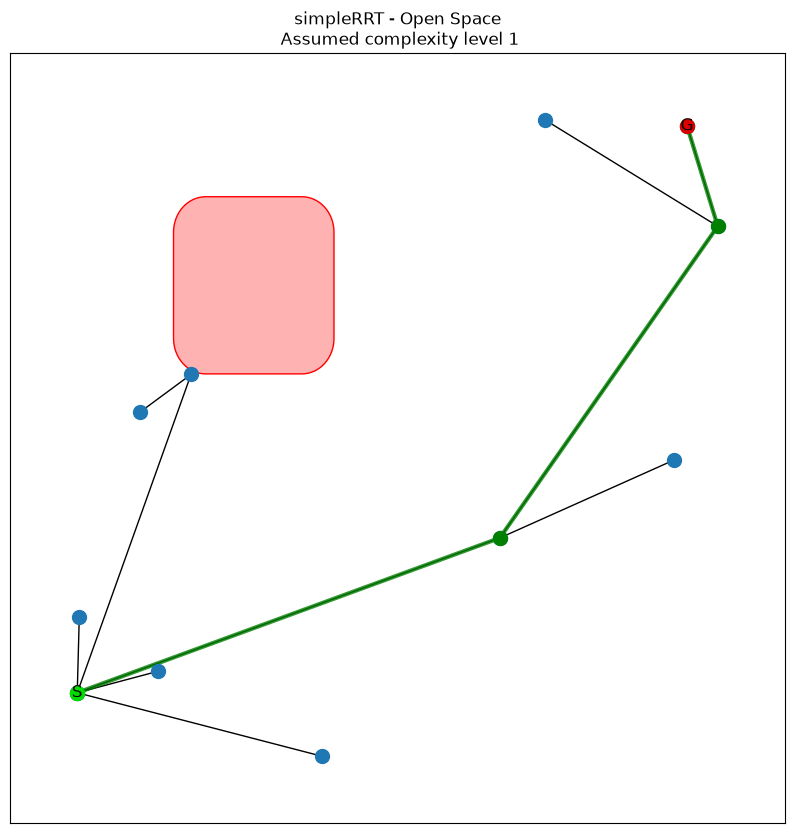

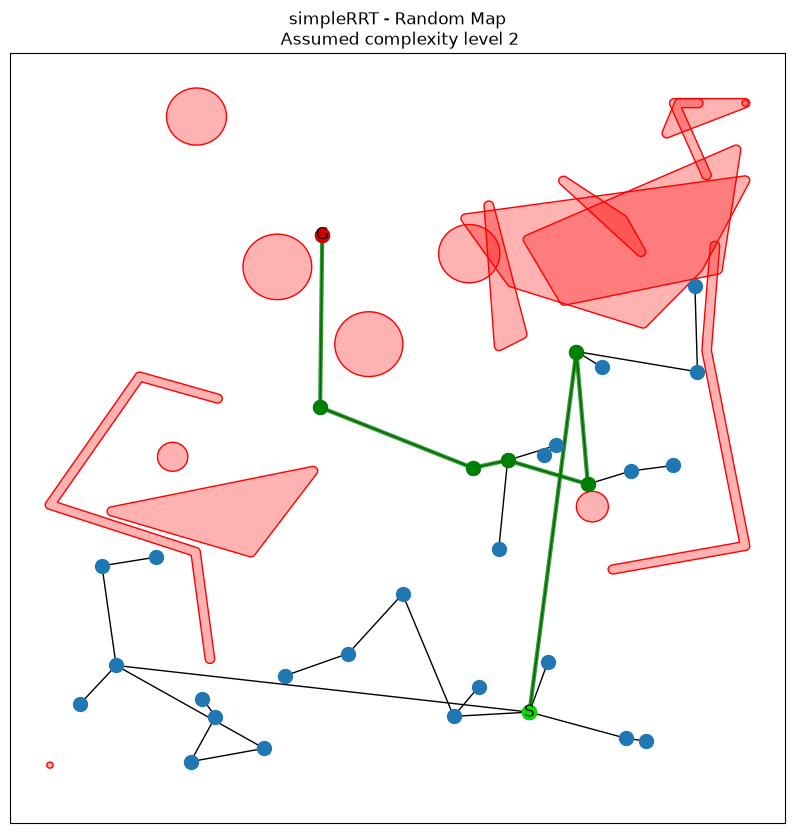

In [9]:
import matplotlib.pyplot as plt

for result in resultList:
    
    fig_local = plt.figure(figsize=(10,10))
    ax = fig_local.add_subplot(1,1,1)
    title = result.plannerFactoryName + " - " + result.benchmark.name
    if result.solution == []:
        title += " (No path found!)"
    title += "\n Assumed complexity level " + str(result.benchmark.level)
    ax.set_title(title)
    try:
        plannerFactory[result.plannerFactoryName][2](result.planner, result.solution, ax=ax, nodeSize=100)
    except Exception as e:
        print ("Error", e)
        pass
    

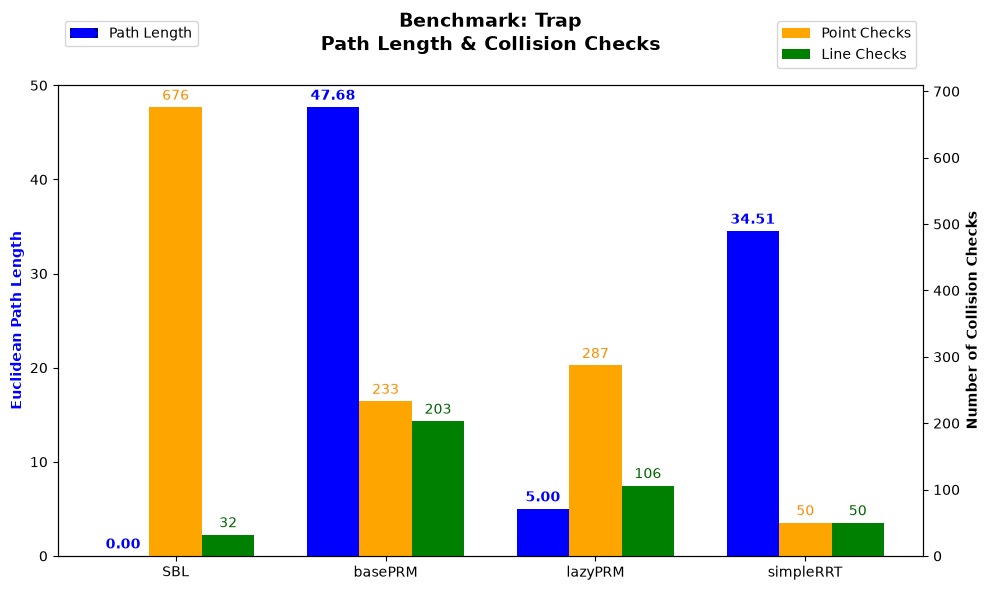

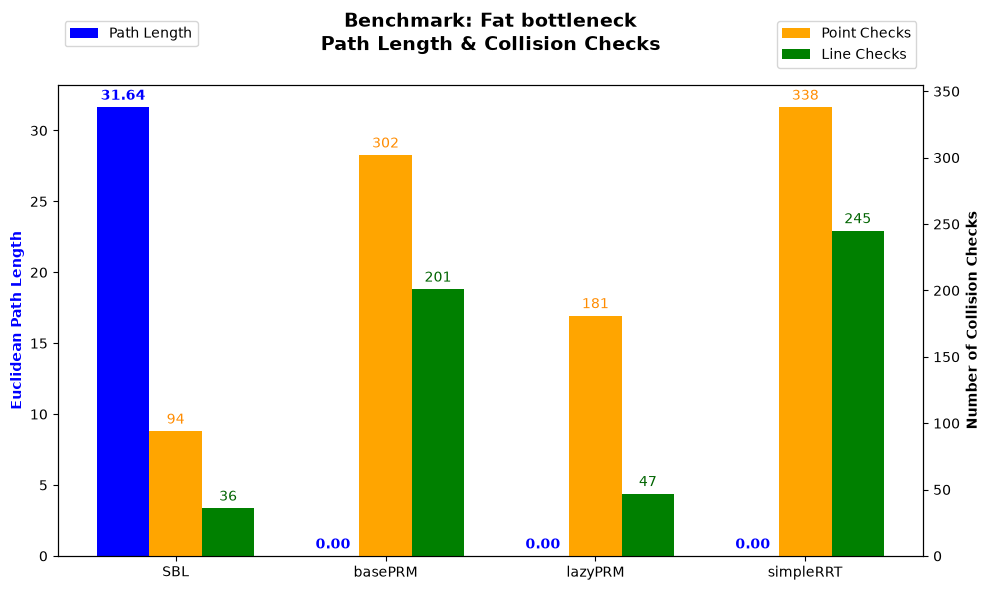

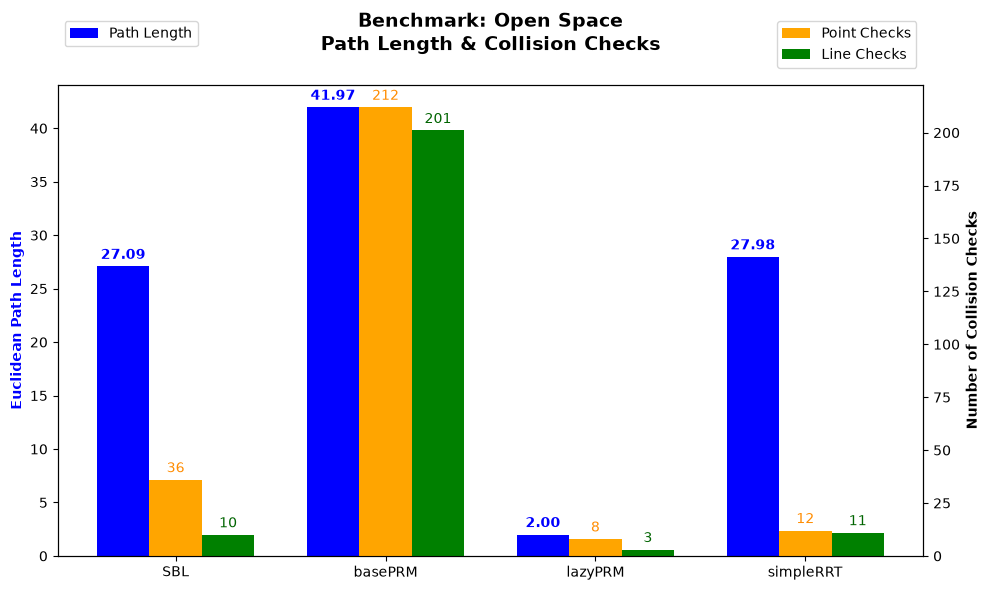

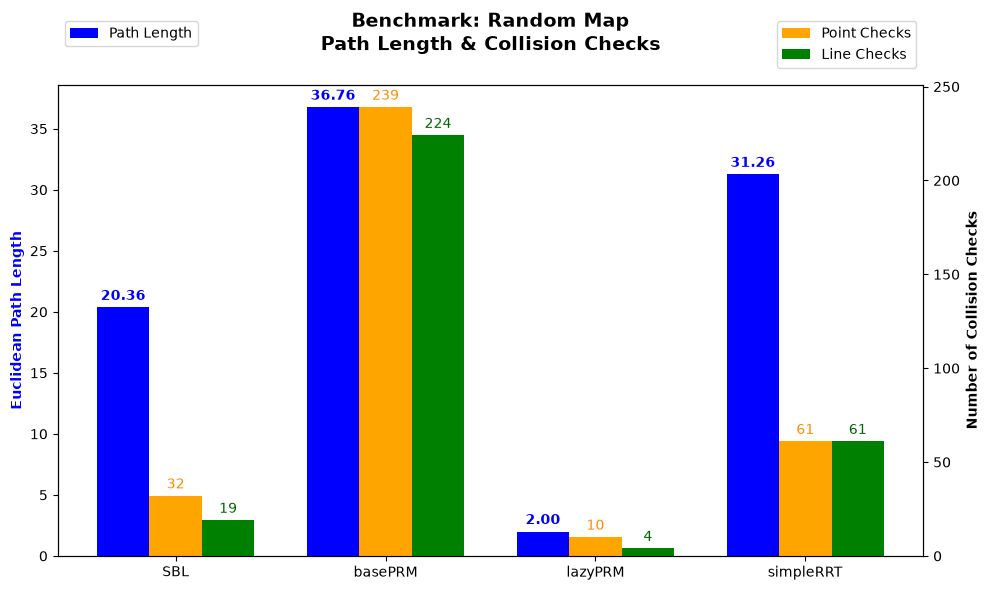

In [11]:
import numpy as np
import matplotlib.pyplot as plt

for bench in testList:
    title = bench.name
    pathLength = dict()
    pointChecks = dict()
    lineChecks = dict()
    
    for result in resultList:
        if result.benchmark.name == bench.name:
            name = result.plannerFactoryName
            
            # --- 1. Path length (UPDATED TO USE EUCLIDEAN LENGTH) ---
            if result.solution and hasattr(result.planner, 'stats'):
                pathLength[name] = result.planner.stats.path_length
            else:
                pathLength[name] = 0.0
            
            # 2. Extract Collision Checks
            point_count = 0
            line_count = 0
            
            # First, try to get counts from the IPPerfMonitor dataframe 
            # (used by BasicPRM, LazyPRM, RRT)
            try:
                if result.perfDataFrame is not None and not result.perfDataFrame.empty:
                    call_counts = result.perfDataFrame.groupby(["name"]).size()
                    point_count = call_counts.get("pointInCollision", 0)
                    line_count = call_counts.get("lineInCollision", 0)
            except (KeyError, AttributeError):
                pass
                
            # If IPPerfMonitor returned 0 (which it will for SBL), 
            # fallback to reading directly from PlannerStats
            if point_count == 0 and line_count == 0 and hasattr(result.planner, 'stats'):
                point_count = result.planner.stats.point_collision_tests
                line_count = result.planner.stats.line_tests
                
            pointChecks[name] = point_count
            lineChecks[name] = line_count

    # Skip plotting if no results were found for this benchmark
    if not pathLength:
        continue

    # --- Plotting Setup ---
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_title(f"Benchmark: {title}\nPath Length & Collision Checks", fontsize=14, fontweight='bold', pad=25)

    width = 0.25
    x_indices = np.arange(len(pathLength.keys()))

    # --- 1. Path Length (Left Axis, Blue) ---
    bar1 = ax.bar(x_indices - width, pathLength.values(), width, color="blue", label="Path Length")
    
    # Labels
    ax.set_ylabel("Euclidean Path Length", color="blue", fontweight='bold')
    ax.set_xticks(x_indices)
    ax.set_xticklabels(pathLength.keys())
    
    # Bar label format: '%.2f' ensures floats print cleanly with 2 decimal places
    ax.bar_label(bar1, padding=3, fmt='%.2f', color="blue", fontweight='bold')
    
    hatches = ['x' if length==0 else '' for length in pathLength.values()]
    for i, thisbar in enumerate(bar1.patches):
        thisbar.set_hatch(hatches[i])

    # --- 2. Collision Checks (Right Axis, Orange & Green) ---
    ax2 = ax.twinx()
    
    # Point checks (Middle bar)
    bar2 = ax2.bar(x_indices, pointChecks.values(), width, color="orange", label="Point Checks")
    # Line checks (Right bar)
    bar3 = ax2.bar(x_indices + width, lineChecks.values(), width, color="green", label="Line Checks")
    
    ax2.set_ylabel("Number of Collision Checks", color="black", fontweight='bold')
    
    # Add labels above the collision check bars
    ax2.bar_label(bar2, padding=3, fmt='%d', color="darkorange")
    ax2.bar_label(bar3, padding=3, fmt='%d', color="darkgreen")

    # Add legends to easily identify the bars
    ax.legend(loc='upper left', bbox_to_anchor=(0, 1.15))
    ax2.legend(loc='upper right', bbox_to_anchor=(1, 1.15))

    # Clean up layout
    plt.tight_layout()
    plt.show()